In [1]:
import pandas as pd

file_path = 'df_bal.csv'
df = pd.read_csv(file_path)

df.head()

,ID_FAM_ANON,VL_RENDA_MEDIA_FAM,IN_TRABALHO_INFANTIL_FAM,CO_MUNIC_IBGE_2_FAM,CO_MUNIC_IBGE_5_FAM,IN_FORMULARIO_SUP2_FAM,QT_PESSOAS_DOMIC_FAM,QT_FAMILIAS_DOMIC_FAM,CO_ESPECIE_DOMIC_FAM,CO_LOCAL_DOMIC_FAM,...,PCT_IDOSOS_60A64,PCT_IDOSOS_BPC,PCT_PES_DEFICIENCIA,TEM_CRIANCA_SEM_ESCOLA,TEM_ADOLESCENTE_SEM_ESCOLA,PCT_PES_ANALFABETA,PCT_ADULTO_NUNCA_FREQ_ESCOLA,PCT_7A18_ESCOLA_PUBLICA,PCT_MENOR6_FORA_CRECHE_PRE,classe_renda
0,5877787,1133.0,2,35,50308,0,2,1,1,1,...,0.0,0.0,0.00,0,0,0.0,0.0,0.000000,0.000000,2
1,6196154,20.0,2,35,23909,0,4,1,1,1,...,0.0,0.0,0.25,0,0,0.0,0.0,0.250000,0.250000,0
2,2623047,432.0,2,26,3454,0,2,1,1,1,...,0.0,0.0,0.00,0,0,0.0,0.0,0.500000,0.000000,1
3,3883198,583.0,2,31,28303,0,6,1,1,1,...,0.0,0.0,0.00,0,0,0.0,0.0,0.333333,0.166667,1
4,3004499,190.0,2,29,27408,0,2,1,1,1,...,0.0,0.0,0.00,0,0,0.0,0.0,0.000000,0.000000,0


In [2]:
df.columns

Index(['ID_FAM_ANON', 'VL_RENDA_MEDIA_FAM', 'IN_TRABALHO_INFANTIL_FAM',
       'CO_MUNIC_IBGE_2_FAM', 'CO_MUNIC_IBGE_5_FAM', 'IN_FORMULARIO_SUP2_FAM',
       'QT_PESSOAS_DOMIC_FAM', 'QT_FAMILIAS_DOMIC_FAM', 'CO_ESPECIE_DOMIC_FAM',
       'CO_LOCAL_DOMIC_FAM', 'QT_COMODOS_DOMIC_FAM',
       'QT_COMODOS_DORMITORIO_FAM', 'CO_MATERIAL_DOMIC_FAM',
       'CO_MATERIAL_PISO_FAM', 'CO_AGUA_CANALIZADA_FAM',
       'CO_ABASTE_AGUA_DOMIC_FAM', 'CO_BANHEIRO_DOMIC_FAM',
       'CO_ESCOA_SANITARIO_DOMIC_FAM', 'CO_ILUMINACAO_DOMIC_FAM',
       'IN_FAMILIA_INDIGENA_FAM', 'IN_FAMILIA_QUILOMBOLA_FAM',
       'IN_PARC_MDS_FAM', 'CO_EST_CADASTRAL_MEMB', 'CO_SEXO_PESSOA',
       'IDADE_REFERENCIA', 'CO_RACA_COR_PESSOA', 'CO_DEFICIENCIA_MEMB',
       'CO_SABE_LER_ESCREVER_MEMB', 'IN_FREQUENTA_ESCOLA_MEMB',
       'CO_CURSO_FREQUENTA_MEMB', 'CO_CURSO_FREQ_PESSOA_MEMB',
       'CO_TRABALHOU_SEMANA_MEMB', 'CO_AFASTADO_TRAB_MEMB',
       'CO_AGRICULTURA_TRAB_MEMB', 'CO_PRINCIPAL_TRAB_MEMB',
       'CO_TRABALHO_

In [3]:
df = df.drop(columns=['VL_RENDA_MEDIA_FAM'])

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999999 entries, 0 to 999998
Data columns (total 51 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   ID_FAM_ANON                   999999 non-null  int64  
 1   IN_TRABALHO_INFANTIL_FAM      999999 non-null  int64  
 2   CO_MUNIC_IBGE_2_FAM           999999 non-null  int64  
 3   CO_MUNIC_IBGE_5_FAM           999999 non-null  int64  
 4   IN_FORMULARIO_SUP2_FAM        999999 non-null  int64  
 5   QT_PESSOAS_DOMIC_FAM          999999 non-null  int64  
 6   QT_FAMILIAS_DOMIC_FAM         999999 non-null  int64  
 7   CO_ESPECIE_DOMIC_FAM          999999 non-null  int64  
 8   CO_LOCAL_DOMIC_FAM            999999 non-null  int64  
 9   QT_COMODOS_DOMIC_FAM          999999 non-null  int64  
 10  QT_COMODOS_DORMITORIO_FAM     999999 non-null  int64  
 11  CO_MATERIAL_DOMIC_FAM         999999 non-null  int64  
 12  CO_MATERIAL_PISO_FAM          999999 non-nul

In [5]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
)

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression


In [6]:
df['classe_renda'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 999999 entries, 0 to 999998
Series name: classe_renda
Non-Null Count   Dtype
--------------   -----
999999 non-null  int64
dtypes: int64(1)
memory usage: 7.6 MB


In [7]:
df.columns

Index(['ID_FAM_ANON', 'IN_TRABALHO_INFANTIL_FAM', 'CO_MUNIC_IBGE_2_FAM',
       'CO_MUNIC_IBGE_5_FAM', 'IN_FORMULARIO_SUP2_FAM', 'QT_PESSOAS_DOMIC_FAM',
       'QT_FAMILIAS_DOMIC_FAM', 'CO_ESPECIE_DOMIC_FAM', 'CO_LOCAL_DOMIC_FAM',
       'QT_COMODOS_DOMIC_FAM', 'QT_COMODOS_DORMITORIO_FAM',
       'CO_MATERIAL_DOMIC_FAM', 'CO_MATERIAL_PISO_FAM',
       'CO_AGUA_CANALIZADA_FAM', 'CO_ABASTE_AGUA_DOMIC_FAM',
       'CO_BANHEIRO_DOMIC_FAM', 'CO_ESCOA_SANITARIO_DOMIC_FAM',
       'CO_ILUMINACAO_DOMIC_FAM', 'IN_FAMILIA_INDIGENA_FAM',
       'IN_FAMILIA_QUILOMBOLA_FAM', 'IN_PARC_MDS_FAM', 'CO_EST_CADASTRAL_MEMB',
       'CO_SEXO_PESSOA', 'IDADE_REFERENCIA', 'CO_RACA_COR_PESSOA',
       'CO_DEFICIENCIA_MEMB', 'CO_SABE_LER_ESCREVER_MEMB',
       'IN_FREQUENTA_ESCOLA_MEMB', 'CO_CURSO_FREQUENTA_MEMB',
       'CO_CURSO_FREQ_PESSOA_MEMB', 'CO_TRABALHOU_SEMANA_MEMB',
       'CO_AFASTADO_TRAB_MEMB', 'CO_AGRICULTURA_TRAB_MEMB',
       'CO_PRINCIPAL_TRAB_MEMB', 'CO_TRABALHO_12_MESES_MEMB', 'QTD_PESSOAS'

## Análise de correlação das variáveis

In [8]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

# ---- 1) Listas das categorias ----

cat_num_cols = [
    'IN_TRABALHO_INFANTIL_FAM', 'IN_FORMULARIO_SUP2_FAM',
    'CO_ESPECIE_DOMIC_FAM', 'CO_LOCAL_DOMIC_FAM',
    'CO_MATERIAL_DOMIC_FAM', 'CO_MATERIAL_PISO_FAM',
    'CO_AGUA_CANALIZADA_FAM', 'CO_ABASTE_AGUA_DOMIC_FAM',
    'CO_BANHEIRO_DOMIC_FAM', 'CO_ESCOA_SANITARIO_DOMIC_FAM',
    'CO_ILUMINACAO_DOMIC_FAM', 'IN_FAMILIA_INDIGENA_FAM',
    'IN_FAMILIA_QUILOMBOLA_FAM', 'IN_PARC_MDS_FAM',
    'CO_EST_CADASTRAL_MEMB', 'CO_SEXO_PESSOA',
    'CO_RACA_COR_PESSOA', 'CO_DEFICIENCIA_MEMB',
    'CO_SABE_LER_ESCREVER_MEMB', 'IN_FREQUENTA_ESCOLA_MEMB',
    'CO_CURSO_FREQUENTA_MEMB', 'CO_CURSO_FREQ_PESSOA_MEMB',
    'CO_TRABALHOU_SEMANA_MEMB', 'CO_AFASTADO_TRAB_MEMB',
    'CO_AGRICULTURA_TRAB_MEMB', 'CO_PRINCIPAL_TRAB_MEMB',
    'CO_TRABALHO_12_MESES_MEMB',
]

bool_cols = [
    'TEM_CRIANCA_SEM_ESCOLA',
    'TEM_ADOLESCENTE_SEM_ESCOLA',
    ]

pct_cols = [
    'PCT_1_INFANCIA', 'PCT_CRIANCAS_7A11',
    'PCT_ADOLESCENTES_12A18', 'PCT_JOVENS_19A29',
    'PCT_ADULTOS_30A59', 'PCT_IDOSOS_60A64',
    'PCT_IDOSOS_BPC', 'PCT_PES_DEFICIENCIA', 'PCT_PES_ANALFABETA',
       'PCT_ADULTO_NUNCA_FREQ_ESCOLA', 'PCT_7A18_ESCOLA_PUBLICA',
       'PCT_MENOR6_FORA_CRECHE_PRE', 
]


quant_cols = [
    'QT_PESSOAS_DOMIC_FAM', 'QT_FAMILIAS_DOMIC_FAM',
    'QT_COMODOS_DOMIC_FAM', 'QT_COMODOS_DORMITORIO_FAM',
    'IDADE_REFERENCIA',
]

# Conjuntos auxiliares para testar tipo rapidamente
cat_all = cat_num_cols + bool_cols    # tratadas como categóricas
num_all = quant_cols + pct_cols                    # tratadas como numéricas

set_cat = set(cat_all)
set_num = set(num_all)

# Todas as variáveis consideradas
all_vars = cat_all + num_all

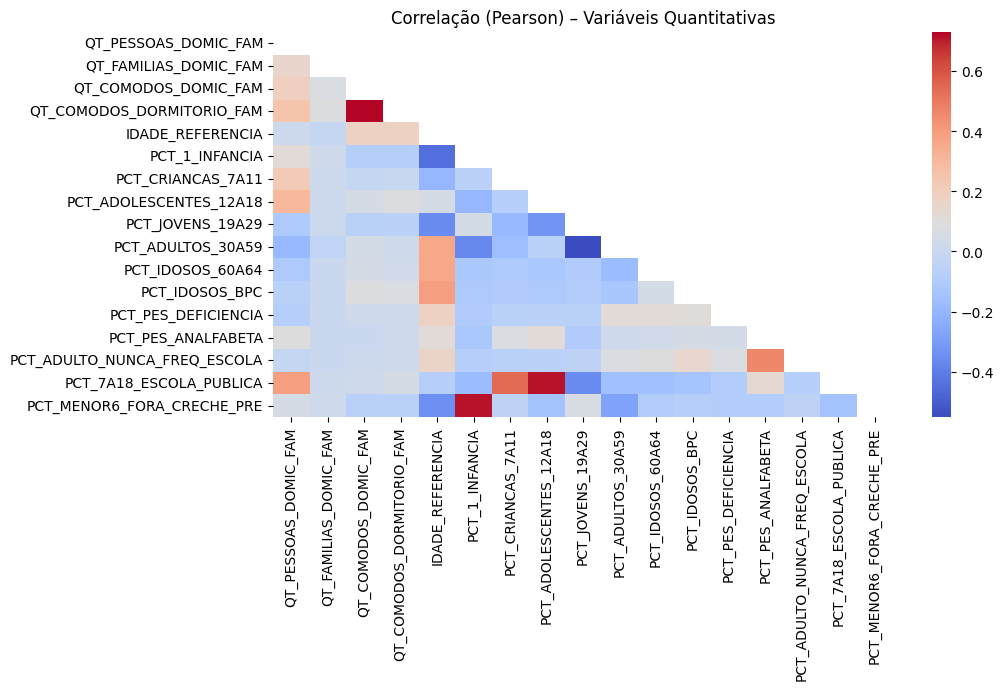

In [9]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Selecionar apenas quantitativas
df_quant = df[quant_cols + pct_cols]

# Matriz de correlação Pearson
corr_quant = df_quant.corr(method='pearson')

# Máscara acima da diagonal
mask = np.triu(np.ones_like(corr_quant, dtype=bool))

plt.figure(figsize=(10, 5))
sns.heatmap(
    corr_quant.round(2),
    annot=False,
    cmap='coolwarm',
    mask=mask
)
plt.title("Correlação (Pearson) – Variáveis Quantitativas")
plt.show()


In [10]:
# Converter matriz para formato longo (var1, var2, corr)
corr_pairs = (
    corr_quant
        .where(np.triu(np.ones(corr_quant.shape), k=1).astype(bool))  # apenas acima da diagonal
        .stack()
        .reset_index()
)
corr_pairs.columns = ['var1', 'var2', 'corr']

# Ordenar pelas correlações mais fortes (em valor absoluto)
corr_pairs_sorted = corr_pairs.reindex(corr_pairs['corr'].abs().sort_values(ascending=False).index)

# Mostrar top 20
corr_pairs_sorted.head(20)


,var1,var2,corr
31,QT_COMODOS_DOMIC_FAM,QT_COMODOS_DORMITORIO_FAM,0.729802
98,PCT_ADOLESCENTES_12A18,PCT_7A18_ESCOLA_PUBLICA,0.711634
80,PCT_1_INFANCIA,PCT_MENOR6_FORA_CRECHE_PRE,0.709086
100,PCT_JOVENS_19A29,PCT_ADULTOS_30A59,-0.554720
89,PCT_CRIANCAS_7A11,PCT_7A18_ESCOLA_PUBLICA,0.544457
130,PCT_PES_ANALFABETA,PCT_ADULTO_NUNCA_FREQ_ESCOLA,0.457566
58,IDADE_REFERENCIA,PCT_1_INFANCIA,-0.453482
64,IDADE_REFERENCIA,PCT_IDOSOS_BPC,0.394302
14,QT_PESSOAS_DOMIC_FAM,PCT_7A18_ESCOLA_PUBLICA,0.389306
73,PCT_1_INFANCIA,PCT_ADULTOS_30A59,-0.370210


In [11]:
THR_CORR = 0.80

corr_fortes = corr_pairs_sorted[
    corr_pairs_sorted["corr"].abs() >= THR_CORR
].copy()

corr_fortes

,var1,var2,corr


In [12]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    t = pd.crosstab(x, y)
    if t.shape[0] <= 1 or t.shape[1] <= 1:
        return np.nan
    chi2, p, dof, expected = chi2_contingency(t)
    n = t.to_numpy().sum()
    r, k = t.shape
    return np.sqrt(chi2 / (n*(min(r,k)-1)))


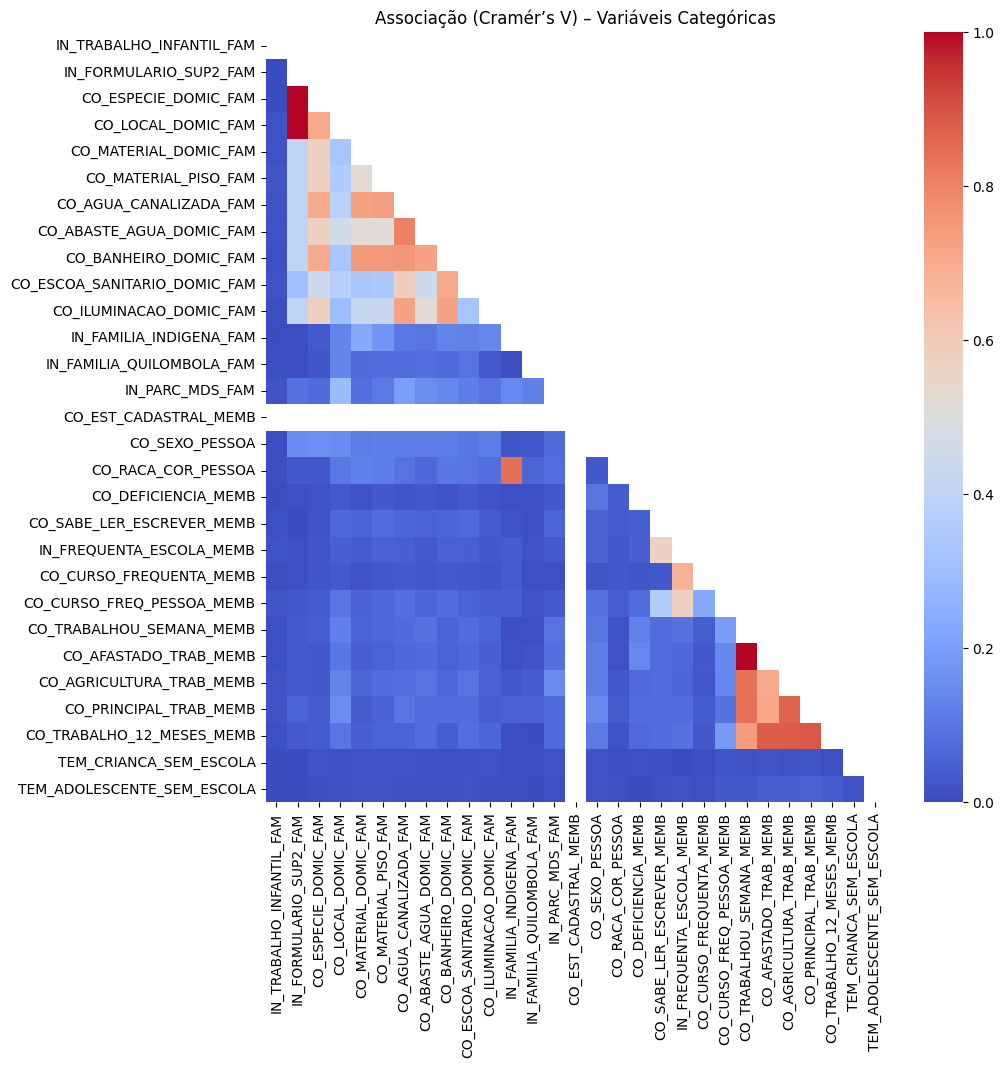

In [13]:
# Selecionar todas as categóricas
df_cat = df[cat_num_cols + bool_cols]

# Matriz vazia
cramers_mat = pd.DataFrame(index=df_cat.columns, columns=df_cat.columns)

# Preencher matriz
for c1 in df_cat.columns:
    for c2 in df_cat.columns:
        if c1 == c2:
            cramers_mat.loc[c1, c2] = 1
        else:
            cramers_mat.loc[c1, c2] = cramers_v(df_cat[c1], df_cat[c2])

# Converter para float
cramers_mat = cramers_mat.astype(float)

# Máscara
mask = np.triu(np.ones_like(cramers_mat, dtype=bool))

plt.figure(figsize=(10, 10))
sns.heatmap(
    cramers_mat,
    annot=False,
    cmap='coolwarm',
    mask=mask,
    vmax=1,
    vmin=0
)
plt.title("Associação (Cramér’s V) – Variáveis Categóricas")
plt.show()


In [14]:
import numpy as np
import pandas as pd

# partindo de cramers_mat já calculada

# 1) Pegar só a parte acima da diagonal para evitar duplicação
cramers_pairs = (
    cramers_mat
        .where(np.triu(np.ones(cramers_mat.shape), k=1).astype(bool))  # mantém só acima da diagonal
        .stack()                                                       # transforma em série longa
        .reset_index()
)

cramers_pairs.columns = ['var1', 'var2', 'cramers_v']

# 2) Ordenar pelas maiores associações
cramers_pairs_sorted = cramers_pairs.sort_values('cramers_v', ascending=False)

# 3) Ver as 30 maiores associações
print("Top 30 pares com maior Cramér's V:")
print(cramers_pairs_sorted.head(10))


Top 30 pares com maior Cramér's V:
                         var1                       var2  cramers_v
357  CO_TRABALHOU_SEMANA_MEMB      CO_AFASTADO_TRAB_MEMB   1.000000
27     IN_FORMULARIO_SUP2_FAM       CO_ESPECIE_DOMIC_FAM   0.999594
28     IN_FORMULARIO_SUP2_FAM         CO_LOCAL_DOMIC_FAM   0.999396
372    CO_PRINCIPAL_TRAB_MEMB  CO_TRABALHO_12_MESES_MEMB   0.888594
369  CO_AGRICULTURA_TRAB_MEMB  CO_TRABALHO_12_MESES_MEMB   0.882046
365     CO_AFASTADO_TRAB_MEMB  CO_TRABALHO_12_MESES_MEMB   0.880279
368  CO_AGRICULTURA_TRAB_MEMB     CO_PRINCIPAL_TRAB_MEMB   0.866327
245   IN_FAMILIA_INDIGENA_FAM         CO_RACA_COR_PESSOA   0.844245
359  CO_TRABALHOU_SEMANA_MEMB     CO_PRINCIPAL_TRAB_MEMB   0.843452
358  CO_TRABALHOU_SEMANA_MEMB   CO_AGRICULTURA_TRAB_MEMB   0.839016


In [15]:
# Definir um limiar para "associação muito alta"
threshold = 0.80

cramers_high = cramers_pairs_sorted[cramers_pairs_sorted['cramers_v'] >= threshold]

print(f"\nPares com Cramér's V >= {threshold}:")
print(cramers_high)



Pares com Cramér's V >= 0.8:
                         var1                       var2  cramers_v
357  CO_TRABALHOU_SEMANA_MEMB      CO_AFASTADO_TRAB_MEMB   1.000000
27     IN_FORMULARIO_SUP2_FAM       CO_ESPECIE_DOMIC_FAM   0.999594
28     IN_FORMULARIO_SUP2_FAM         CO_LOCAL_DOMIC_FAM   0.999396
372    CO_PRINCIPAL_TRAB_MEMB  CO_TRABALHO_12_MESES_MEMB   0.888594
369  CO_AGRICULTURA_TRAB_MEMB  CO_TRABALHO_12_MESES_MEMB   0.882046
365     CO_AFASTADO_TRAB_MEMB  CO_TRABALHO_12_MESES_MEMB   0.880279
368  CO_AGRICULTURA_TRAB_MEMB     CO_PRINCIPAL_TRAB_MEMB   0.866327
245   IN_FAMILIA_INDIGENA_FAM         CO_RACA_COR_PESSOA   0.844245
359  CO_TRABALHOU_SEMANA_MEMB     CO_PRINCIPAL_TRAB_MEMB   0.843452
358  CO_TRABALHOU_SEMANA_MEMB   CO_AGRICULTURA_TRAB_MEMB   0.839016
147    CO_AGUA_CANALIZADA_FAM   CO_ABASTE_AGUA_DOMIC_FAM   0.807989


In [16]:
df = df.drop(columns=['IN_FORMULARIO_SUP2_FAM', 'CO_PRINCIPAL_TRAB_MEMB', 'CO_TRABALHOU_SEMANA_MEMB', 'CO_AGRICULTURA_TRAB_MEMB', 'CO_AFASTADO_TRAB_MEMB', 'IN_FAMILIA_INDIGENA_FAM', 'CO_AGUA_CANALIZADA_FAM'])

In [17]:
df.columns

Index(['ID_FAM_ANON', 'IN_TRABALHO_INFANTIL_FAM', 'CO_MUNIC_IBGE_2_FAM',
       'CO_MUNIC_IBGE_5_FAM', 'QT_PESSOAS_DOMIC_FAM', 'QT_FAMILIAS_DOMIC_FAM',
       'CO_ESPECIE_DOMIC_FAM', 'CO_LOCAL_DOMIC_FAM', 'QT_COMODOS_DOMIC_FAM',
       'QT_COMODOS_DORMITORIO_FAM', 'CO_MATERIAL_DOMIC_FAM',
       'CO_MATERIAL_PISO_FAM', 'CO_ABASTE_AGUA_DOMIC_FAM',
       'CO_BANHEIRO_DOMIC_FAM', 'CO_ESCOA_SANITARIO_DOMIC_FAM',
       'CO_ILUMINACAO_DOMIC_FAM', 'IN_FAMILIA_QUILOMBOLA_FAM',
       'IN_PARC_MDS_FAM', 'CO_EST_CADASTRAL_MEMB', 'CO_SEXO_PESSOA',
       'IDADE_REFERENCIA', 'CO_RACA_COR_PESSOA', 'CO_DEFICIENCIA_MEMB',
       'CO_SABE_LER_ESCREVER_MEMB', 'IN_FREQUENTA_ESCOLA_MEMB',
       'CO_CURSO_FREQUENTA_MEMB', 'CO_CURSO_FREQ_PESSOA_MEMB',
       'CO_TRABALHO_12_MESES_MEMB', 'QTD_PESSOAS', 'PCT_1_INFANCIA',
       'PCT_CRIANCAS_7A11', 'PCT_ADOLESCENTES_12A18', 'PCT_JOVENS_19A29',
       'PCT_ADULTOS_30A59', 'PCT_IDOSOS_60A64', 'PCT_IDOSOS_BPC',
       'PCT_PES_DEFICIENCIA', 'TEM_CRIANCA_SEM_

In [18]:
df.head()

,ID_FAM_ANON,IN_TRABALHO_INFANTIL_FAM,CO_MUNIC_IBGE_2_FAM,CO_MUNIC_IBGE_5_FAM,QT_PESSOAS_DOMIC_FAM,QT_FAMILIAS_DOMIC_FAM,CO_ESPECIE_DOMIC_FAM,CO_LOCAL_DOMIC_FAM,QT_COMODOS_DOMIC_FAM,QT_COMODOS_DORMITORIO_FAM,...,PCT_IDOSOS_60A64,PCT_IDOSOS_BPC,PCT_PES_DEFICIENCIA,TEM_CRIANCA_SEM_ESCOLA,TEM_ADOLESCENTE_SEM_ESCOLA,PCT_PES_ANALFABETA,PCT_ADULTO_NUNCA_FREQ_ESCOLA,PCT_7A18_ESCOLA_PUBLICA,PCT_MENOR6_FORA_CRECHE_PRE,classe_renda
0,5877787,2,35,50308,2,1,1,1,3,1,...,0.0,0.0,0.00,0,0,0.0,0.0,0.000000,0.000000,2
1,6196154,2,35,23909,4,1,1,1,5,2,...,0.0,0.0,0.25,0,0,0.0,0.0,0.250000,0.250000,0
2,2623047,2,26,3454,2,1,1,1,2,1,...,0.0,0.0,0.00,0,0,0.0,0.0,0.500000,0.000000,1
3,3883198,2,31,28303,6,1,1,1,5,2,...,0.0,0.0,0.00,0,0,0.0,0.0,0.333333,0.166667,1
4,3004499,2,29,27408,2,1,1,1,2,1,...,0.0,0.0,0.00,0,0,0.0,0.0,0.000000,0.000000,0


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999999 entries, 0 to 999998
Data columns (total 44 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   ID_FAM_ANON                   999999 non-null  int64  
 1   IN_TRABALHO_INFANTIL_FAM      999999 non-null  int64  
 2   CO_MUNIC_IBGE_2_FAM           999999 non-null  int64  
 3   CO_MUNIC_IBGE_5_FAM           999999 non-null  int64  
 4   QT_PESSOAS_DOMIC_FAM          999999 non-null  int64  
 5   QT_FAMILIAS_DOMIC_FAM         999999 non-null  int64  
 6   CO_ESPECIE_DOMIC_FAM          999999 non-null  int64  
 7   CO_LOCAL_DOMIC_FAM            999999 non-null  int64  
 8   QT_COMODOS_DOMIC_FAM          999999 non-null  int64  
 9   QT_COMODOS_DORMITORIO_FAM     999999 non-null  int64  
 10  CO_MATERIAL_DOMIC_FAM         999999 non-null  int64  
 11  CO_MATERIAL_PISO_FAM          999999 non-null  int64  
 12  CO_ABASTE_AGUA_DOMIC_FAM      999999 non-nul

## Pre-processamento
### Detectando as colunas categóricas binárias e multicategóricas

In [20]:
df.columns

Index(['ID_FAM_ANON', 'IN_TRABALHO_INFANTIL_FAM', 'CO_MUNIC_IBGE_2_FAM',
       'CO_MUNIC_IBGE_5_FAM', 'QT_PESSOAS_DOMIC_FAM', 'QT_FAMILIAS_DOMIC_FAM',
       'CO_ESPECIE_DOMIC_FAM', 'CO_LOCAL_DOMIC_FAM', 'QT_COMODOS_DOMIC_FAM',
       'QT_COMODOS_DORMITORIO_FAM', 'CO_MATERIAL_DOMIC_FAM',
       'CO_MATERIAL_PISO_FAM', 'CO_ABASTE_AGUA_DOMIC_FAM',
       'CO_BANHEIRO_DOMIC_FAM', 'CO_ESCOA_SANITARIO_DOMIC_FAM',
       'CO_ILUMINACAO_DOMIC_FAM', 'IN_FAMILIA_QUILOMBOLA_FAM',
       'IN_PARC_MDS_FAM', 'CO_EST_CADASTRAL_MEMB', 'CO_SEXO_PESSOA',
       'IDADE_REFERENCIA', 'CO_RACA_COR_PESSOA', 'CO_DEFICIENCIA_MEMB',
       'CO_SABE_LER_ESCREVER_MEMB', 'IN_FREQUENTA_ESCOLA_MEMB',
       'CO_CURSO_FREQUENTA_MEMB', 'CO_CURSO_FREQ_PESSOA_MEMB',
       'CO_TRABALHO_12_MESES_MEMB', 'QTD_PESSOAS', 'PCT_1_INFANCIA',
       'PCT_CRIANCAS_7A11', 'PCT_ADOLESCENTES_12A18', 'PCT_JOVENS_19A29',
       'PCT_ADULTOS_30A59', 'PCT_IDOSOS_60A64', 'PCT_IDOSOS_BPC',
       'PCT_PES_DEFICIENCIA', 'TEM_CRIANCA_SEM_

In [21]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np

# Listas de cada categoria
cat_num_cols = [
    'IN_TRABALHO_INFANTIL_FAM', 
    'CO_ESPECIE_DOMIC_FAM', 'CO_LOCAL_DOMIC_FAM',
    'CO_MATERIAL_DOMIC_FAM', 'CO_MATERIAL_PISO_FAM',
    'CO_ABASTE_AGUA_DOMIC_FAM', 
    'CO_BANHEIRO_DOMIC_FAM', 'CO_ESCOA_SANITARIO_DOMIC_FAM',
    'CO_ILUMINACAO_DOMIC_FAM', 
    'IN_FAMILIA_QUILOMBOLA_FAM', 'IN_PARC_MDS_FAM',
    'CO_EST_CADASTRAL_MEMB', 'CO_SEXO_PESSOA',
    'CO_RACA_COR_PESSOA', 'CO_DEFICIENCIA_MEMB',
    'CO_SABE_LER_ESCREVER_MEMB', 'IN_FREQUENTA_ESCOLA_MEMB', 'CO_CURSO_FREQUENTA_MEMB', 
    'CO_CURSO_FREQ_PESSOA_MEMB', 'CO_TRABALHO_12_MESES_MEMB',
    ]

bool_cols = [
        'TEM_CRIANCA_SEM_ESCOLA',
        'TEM_ADOLESCENTE_SEM_ESCOLA',
        ]

pct_cols = [
         'PCT_1_INFANCIA', 'PCT_CRIANCAS_7A11',
      'PCT_ADOLESCENTES_12A18', 'PCT_JOVENS_19A29',
      'PCT_ADULTOS_30A59', 'PCT_IDOSOS_60A64',
      'PCT_IDOSOS_BPC', 'PCT_PES_DEFICIENCIA', 'PCT_PES_ANALFABETA',
       'PCT_ADULTO_NUNCA_FREQ_ESCOLA', 'PCT_7A18_ESCOLA_PUBLICA',
       'PCT_MENOR6_FORA_CRECHE_PRE',
    ]

quant_cols = [
        'QT_PESSOAS_DOMIC_FAM', 'QT_FAMILIAS_DOMIC_FAM',
        'QT_COMODOS_DOMIC_FAM', 'QT_COMODOS_DORMITORIO_FAM',
        'IDADE_REFERENCIA',
    ]

geo_cols = ['CO_MUNIC_IBGE_2_FAM', 'CO_MUNIC_IBGE_5_FAM']

target_col = "classe_renda"
id_col = "ID_FAM_ANON"


In [22]:
# X e y brutos
X = df.drop(columns=[target_col, id_col])
y = df[target_col]

# Garante que as listas só pegam colunas que realmente existem
cat_num_cols_eff = [c for c in cat_num_cols if c in X.columns]
bool_cols_eff    = [c for c in bool_cols    if c in X.columns]
pct_cols_eff     = [c for c in pct_cols     if c in X.columns]
quant_cols_eff   = [c for c in quant_cols   if c in X.columns]
geo_cols_eff     = [c for c in geo_cols     if c in X.columns]

# Detectar binárias e multicategóricas dentro de cat_num_cols
binary_cols = []
multicat_cols = []

for col in cat_num_cols_eff:
    n_unique = X[col].nunique()
    if n_unique == 2:
        binary_cols.append(col)
    elif n_unique > 2:
        multicat_cols.append(col)

print("Binárias:", binary_cols)
print("Multicategóricas:", multicat_cols)

Binárias: ['IN_TRABALHO_INFANTIL_FAM', 'IN_FAMILIA_QUILOMBOLA_FAM', 'CO_SEXO_PESSOA', 'CO_DEFICIENCIA_MEMB', 'CO_SABE_LER_ESCREVER_MEMB', 'CO_TRABALHO_12_MESES_MEMB']
Multicategóricas: ['CO_ESPECIE_DOMIC_FAM', 'CO_LOCAL_DOMIC_FAM', 'CO_MATERIAL_DOMIC_FAM', 'CO_MATERIAL_PISO_FAM', 'CO_ABASTE_AGUA_DOMIC_FAM', 'CO_BANHEIRO_DOMIC_FAM', 'CO_ESCOA_SANITARIO_DOMIC_FAM', 'CO_ILUMINACAO_DOMIC_FAM', 'IN_PARC_MDS_FAM', 'CO_RACA_COR_PESSOA', 'IN_FREQUENTA_ESCOLA_MEMB', 'CO_CURSO_FREQUENTA_MEMB', 'CO_CURSO_FREQ_PESSOA_MEMB']


In [23]:
# Pipeline quantitativas contínuas
pipeline_quant = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", MinMaxScaler()),
])

In [24]:
#Pipeline categorias multiclasses (One-hot)
pipeline_multicat = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

In [25]:
# Pipeline para binárias
pipeline_binary = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ])


In [26]:
# Pipeline percentuais (já estão entre 0 e 1)
pipeline_pct = "passthrough"

In [27]:
# Pipeline booleanas
pipeline_bool = "passthrough"

In [28]:
#Pipeline geográficas (não usar one-hot pois vai criar muitas colunas)
pipeline_geo = "passthrough"

In [29]:
#Construindo ColumnsTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("quant", pipeline_quant, quant_cols),
        ("pct", pipeline_pct, pct_cols),
        ("bool", pipeline_bool, bool_cols),
        ("binary", pipeline_binary, binary_cols),
        ("multicat", pipeline_multicat, multicat_cols),
        ("geo", pipeline_geo, geo_cols),
    ],
    remainder="drop"  # remove colunas que não foram especificadas
)

## Separando em treino e teste

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Visualizando a transformação

In [31]:
preprocessor.fit(X_train)

ColumnTransformer(transformers=[('quant',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='median')),
                                                 ('scale', MinMaxScaler())]),
                                 ['QT_PESSOAS_DOMIC_FAM',
                                  'QT_FAMILIAS_DOMIC_FAM',
                                  'QT_COMODOS_DOMIC_FAM',
                                  'QT_COMODOS_DORMITORIO_FAM',
                                  'IDADE_REFERENCIA']),
                                ('pct', 'passthrough',
                                 ['PCT_1_INFANCIA', 'PCT_CRIANCAS_7A11',
                                  'PCT_ADOLESCENTES_12A18', 'PCT_JOVENS_19A29'...
                                 ['CO_ESPECIE_DOMIC_FAM', 'CO_LOCAL_DOMIC_FAM',
                                  'CO_MATERIAL_DOMIC_FAM',
                                  'CO_MATERIAL_PISO_FAM',
                                  'CO_ABASTE_AGUA_DOMIC_FAM',
                                  'CO_BANHEIRO_DOMIC_FAM',
                                  'CO_ESCOA_SANITARIO_DOMIC_FAM',
                                  'CO_ILUMINACAO_DOMIC_FAM', 'IN_PARC_MDS_FAM',
                                  'CO_RACA_COR_PESSOA',
                                  'IN_FREQUENTA_ESCOLA_MEMB',
                                  'CO_CURSO_FREQUENTA_MEMB',
                                  'CO_CURSO_FREQ_PESSOA_MEMB']),
                                ('geo', 'passthrough',
                                 ['CO_MUNIC_IBGE_2_FAM',
                                  'CO_MUNIC_IBGE_5_FAM'])])

In [32]:
X_train_trans = preprocessor.transform(X_train)

feature_names = preprocessor.get_feature_names_out()

import pandas as pd
df_train_trans = pd.DataFrame(X_train_trans, columns=feature_names)

df_train_trans.head()

,quant__QT_PESSOAS_DOMIC_FAM,quant__QT_FAMILIAS_DOMIC_FAM,quant__QT_COMODOS_DOMIC_FAM,quant__QT_COMODOS_DORMITORIO_FAM,quant__IDADE_REFERENCIA,pct__PCT_1_INFANCIA,pct__PCT_CRIANCAS_7A11,pct__PCT_ADOLESCENTES_12A18,pct__PCT_JOVENS_19A29,pct__PCT_ADULTOS_30A59,...,multicat__CO_CURSO_FREQ_PESSOA_MEMB_8,multicat__CO_CURSO_FREQ_PESSOA_MEMB_9,multicat__CO_CURSO_FREQ_PESSOA_MEMB_10,multicat__CO_CURSO_FREQ_PESSOA_MEMB_11,multicat__CO_CURSO_FREQ_PESSOA_MEMB_12,multicat__CO_CURSO_FREQ_PESSOA_MEMB_13,multicat__CO_CURSO_FREQ_PESSOA_MEMB_14,multicat__CO_CURSO_FREQ_PESSOA_MEMB_15,geo__CO_MUNIC_IBGE_2_FAM,geo__CO_MUNIC_IBGE_5_FAM
0,0.06,0.020202,0.031915,0.029412,0.379310,0.166667,0.166667,0.333333,0.0,0.333333,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,50.0,6200.0
1,0.04,0.020202,0.074468,0.058824,0.528736,0.000000,0.000000,0.000000,0.0,0.333333,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,50.0,4007.0
2,0.04,0.020202,0.042553,0.029412,0.241379,0.666667,0.000000,0.000000,0.0,0.333333,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,43.0,21105.0
3,0.03,0.020202,0.053191,0.044118,0.160920,0.000000,0.000000,0.000000,0.0,1.000000,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,17.0,21000.0
4,0.06,0.020202,0.053191,0.044118,0.252874,0.000000,0.200000,0.600000,0.0,0.200000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,43.0,10330.0


### Comparando diversos modelos

In [33]:
!pip install xgboost --quiet


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [34]:
!pip install catboost --quiet


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [37]:
# ============================================================
# PASSO 1 — Corrigir o preprocessor para economizar memória
# ============================================================
# Redefine apenas o pipeline_multicat com sparse_output=True
# e reconstrói o preprocessor. Tudo o mais já está no notebook.

from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Corrige: sparse_output=True + max_categories=20
pipeline_multicat = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=True,       # <-- era False, causava MemoryError
        max_categories=20         # <-- limita expansão de colunas
    )),
])

# Reconstrói o preprocessor (os demais pipelines já existem no notebook)
preprocessor = ColumnTransformer(
    transformers=[
        ("quant",    pipeline_quant,   quant_cols),
        ("pct",      pipeline_pct,     pct_cols),
        ("bool",     pipeline_bool,    bool_cols),
        ("binary",   pipeline_binary,  binary_cols),
        ("multicat", pipeline_multicat, multicat_cols),
        ("geo",      pipeline_geo,     geo_cols),
    ],
    remainder="drop",
    sparse_threshold=0.3   # mantém esparso se >30% das colunas forem esparsas
)

# ============================================================
# PASSO 2 — Modelos
# ============================================================
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    precision_score, recall_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, HistGradientBoostingClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

models = {
    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softprob",
        eval_metric="mlogloss",
        tree_method="hist",
        random_state=42,
        n_jobs=-1
    ),
    "CatBoost": CatBoostClassifier(
        iterations=300,
        learning_rate=0.1,
        depth=6,
        loss_function="MultiClass",
        eval_metric="MultiClass",
        random_seed=42,
        verbose=False,
        allow_writing_files=False
    ),
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=42),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "LogisticRegression": LogisticRegression(
        max_iter=1000, multi_class="auto", n_jobs=-1
    ),
}

# ============================================================
# PASSO 3 — Treino + Avaliação
# ============================================================
pipes = {}
results = []

for name, clf in models.items():
    print(f"\nTreinando modelo: {name}")

    pipe = Pipeline([
        ("preprocess", preprocessor),
        ("model", clf)
    ])

    try:
        pipe.fit(X_train, y_train)
    except MemoryError:
        print(f"  MemoryError ao treinar {name} — pulando este modelo.")
        continue

    pipes[name] = pipe

    y_pred = pipe.predict(X_test).ravel()

    acc    = accuracy_score(y_test, y_pred)
    f1_w   = f1_score(y_test, y_pred, average="weighted")
    f1_m   = f1_score(y_test, y_pred, average="macro")
    prec_m = precision_score(y_test, y_pred, average="macro", zero_division=0)
    rec_m  = recall_score(y_test, y_pred, average="macro", zero_division=0)
    prec_w = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec_w  = recall_score(y_test, y_pred, average="weighted", zero_division=0)

    try:
        y_proba = pipe.predict_proba(X_test)
        auc = roc_auc_score(y_test, y_proba, multi_class="ovr", average="weighted")
    except Exception:
        auc = np.nan

    results.append({
        "modelo": name,
        "accuracy": acc,
        "f1_weighted": f1_w,
        "f1_macro": f1_m,
        "precision_macro": prec_m,
        "recall_macro": rec_m,
        "precision_weighted": prec_w,
        "recall_weighted": rec_w,
        "auc_weighted_ovr": auc,
    })

    print(f"  Accuracy: {acc:.4f} | F1 macro: {f1_m:.4f} | AUC: {auc:.4f}")

# ============================================================
# PASSO 4 — Resultados
# ============================================================
df_results = pd.DataFrame(results).sort_values("accuracy", ascending=False)
df_results



Treinando modelo: XGBoost
  Accuracy: 0.5619 | F1 macro: 0.5545 | AUC: 0.7537

Treinando modelo: CatBoost
  Accuracy: 0.5594 | F1 macro: 0.5521 | AUC: 0.7508

Treinando modelo: HistGradientBoosting
  Accuracy: 0.5610 | F1 macro: 0.5538 | AUC: 0.7522

Treinando modelo: GradientBoosting
  Accuracy: 0.5487 | F1 macro: 0.5409 | AUC: 0.7389

Treinando modelo: LogisticRegression


C:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  Accuracy: 0.5066 | F1 macro: 0.4988 | AUC: 0.6927


,modelo,accuracy,f1_weighted,f1_macro,precision_macro,recall_macro,precision_weighted,recall_weighted,auc_weighted_ovr
0,XGBoost,0.561935,0.554528,0.554528,0.554664,0.561935,0.554664,0.561935,0.753663
2,HistGradientBoosting,0.561035,0.553792,0.553793,0.553969,0.561035,0.553969,0.561035,0.752210
1,CatBoost,0.559415,0.552094,0.552094,0.552287,0.559415,0.552287,0.559415,0.750781
3,GradientBoosting,0.548680,0.540899,0.540899,0.540990,0.548680,0.540990,0.548680,0.738944
4,LogisticRegression,0.506555,0.498762,0.498762,0.497395,0.506555,0.497395,0.506555,0.692720


### O balanceamento no multiclasse piorou a acurácia e o AUC, caindo de 65,3% para 56,2% em accuracy e de 0.78 para 0.75 em AUC. O modelo ficou menos capaz de discriminar as classes no geral.
### O recall macro subiu (de 0.51 para 0.56), o que era esperado — o balanceamento força o modelo a prestar mais atenção às classes minoritárias. Porém, isso veio com uma queda forte na precision macro (de 0.61 para 0.55), gerando mais classificações erradas em todas as faixas.
### O trade-off não compensou. O ganho de ~5 pontos em recall macro não justifica a perda de ~10 pontos em accuracy e ~6 pontos em precision. O modelo multiclasse balanceado acerta pouco mais da metade das famílias — um nível que torna a classificação por faixa pouco confiável para uso em averiguação cadastral.
### O modelo binário proporcional continua amplamente superior em todos os aspectos relevantes:
#### Accuracy 19 pontos acima
#### AUC 8 pontos acima
#### Precision e recall da classe positiva ambos acima de 0.74, permitindo convocações mais assertivas
#### No threshold 0.80, a precision chega a 0.89, o que significa que quase 9 em cada 10 convocações são corretas